In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
data = pd.read_csv("logs/singleImage/OMP/centerRevFftstatandDynTGaussIfft.csv", sep=' ', header=0)

In [6]:
statDyn = data.groupby(["threads", 'N'])[["FFTStat", "FFTDyn"]].agg(["mean", "std"])*100

In [7]:
statDyn

FFTStat                FFTDyn          
                     mean       std        mean       std
threads N                                                
2       512      0.225584  0.018664    0.223033  0.002708
        1024     0.969687  0.020579    0.965791  0.008547
        2048     4.201827  0.097958    4.178425  0.058271
        4096    18.735305  0.197530   18.600970  0.202340
        8192    80.064154  0.657995   80.187923  0.601104
        16384  344.450750  2.033797  344.750860  2.284473
3       512      0.151369  0.009866    0.150534  0.001177
        1024     0.654175  0.021971    0.649696  0.004363
        2048     2.783695  0.023464    2.782980  0.022423
        4096    12.496176  0.054887   12.475707  0.052486
        8192    54.625719  0.362622   54.577179  0.338998
        16384  237.118810  1.894262  237.420890  1.968027
4       512      0.146581  0.044389    0.127515  0.016599
        1024     0.705007  0.216927    0.571439  0.080345
        2048     2.797454  0.477673    2.129677  0.034083
        4096     9.725935  0.105078    9.788226  0.049487
        8192    43.228454  0.114581   43.262693  0.058511
        16384  186.430980  0.271561  186.399020  0.293186
5       512      0.165961  0.005499    0.114577  0.005931
        1024     0.749492  0.033524    0.503076  0.023908
        2048     3.390086  0.112863    2.123158  0.045956
        4096    12.556535  0.439371    9.537331  0.120678
        8192    51.202856  0.493154   42.508916  0.602286
        16384  210.905670  2.930938  178.459270  3.992414
6       512      0.143664  0.023516    0.109075  0.001630
        1024     0.609435  0.023995    0.475345  0.011385
        2048     2.722132  0.055622    2.060328  0.014381
        4096    11.340346  0.358381    9.101567  0.073387
        8192    42.793561  0.651041   40.376025  0.582368
        16384  179.458700  1.663682  177.322640  2.237992
7       512      0.126808  0.032164    0.113511  0.049899
        1024     0.529929  0.022508    0.474379  0.010478
        2048     2.400539  0.113481    2.079548  0.024604
        4096    10.380141  0.171181    9.174903  0.102165
        8192    43.494017  0.531144   40.295076  0.272729
        16384  178.666570  1.268265  175.654160  1.321229
8       512      0.223184  0.175513    0.197699  0.178710
        1024     0.566102  0.208612    0.533741  0.188004
        2048     2.319330  0.447466    2.055186  0.022858
        4096     9.201339  0.196098    9.150142  0.035088
        8192    40.158762  0.129368   39.963369  0.140027
        16384  175.672920  0.461004  174.731860  0.503498

In [8]:
data = pd.read_csv("logs/cuda/finalSetup/times.csv", sep=' ', header=None, names=["N", "real", "user", "sys"])
data.groupby('N').agg(["mean", "std"])*1000

real                user               sys           
          mean        std     mean       std    mean        std
N                                                              
512     186.26  26.864651    15.64  2.422621  153.44  26.580664
1024    193.84   6.845658    20.71  2.854360  155.87   4.885879
2048    213.23   6.795505    36.85  2.475639  159.78   4.678729
4096    302.63   4.628971   106.22  2.258899  180.58   3.779744
8192    676.52   4.164496   397.25  2.384186  262.48   3.063239
16384  2212.66   4.870484  1617.10  4.171815  578.16   3.532590

In [90]:
statDyn["FFTDyn"].unstack()

mean                                                         std  \
N          512       1024      2048      4096      8192      16384     512     
thread                                                                         
2       0.002362  0.009789  0.041574  0.184773  0.801881  3.443225  0.000362   
3       0.001520  0.006514  0.027738  0.124007  0.535800  2.298390  0.000063   
4       0.001284  0.005404  0.020946  0.092897  0.411771  1.783838  0.000155   
5       0.001120  0.004856  0.020782  0.091974  0.405351  1.753805  0.000026   
6       0.001089  0.004729  0.020576  0.093122  0.404520  1.766780  0.000008   
7       0.001078  0.004746  0.020688  0.091374  0.400943  1.752708  0.000064   
8       0.002430  0.005352  0.020603  0.091874  0.400775  1.756345  0.001846   

                                                          
N          1024      2048      4096      8192      16384  
thread                                                    
2       0.000150  0.000268  0.002626  0.006562  0.020914  
3       0.000216  0.000101  0.000584  0.001036  0.003390  
4       0.000676  0.000060  0.000295  0.000795  0.003596  
5       0.000145  0.000388  0.000501  0.005216  0.019866  
6       0.000023  0.000119  0.005683  0.007125  0.024039  
7       0.000199  0.000253  0.001123  0.004320  0.015386  
8       0.001741  0.000233  0.000264  0.001440  0.005808

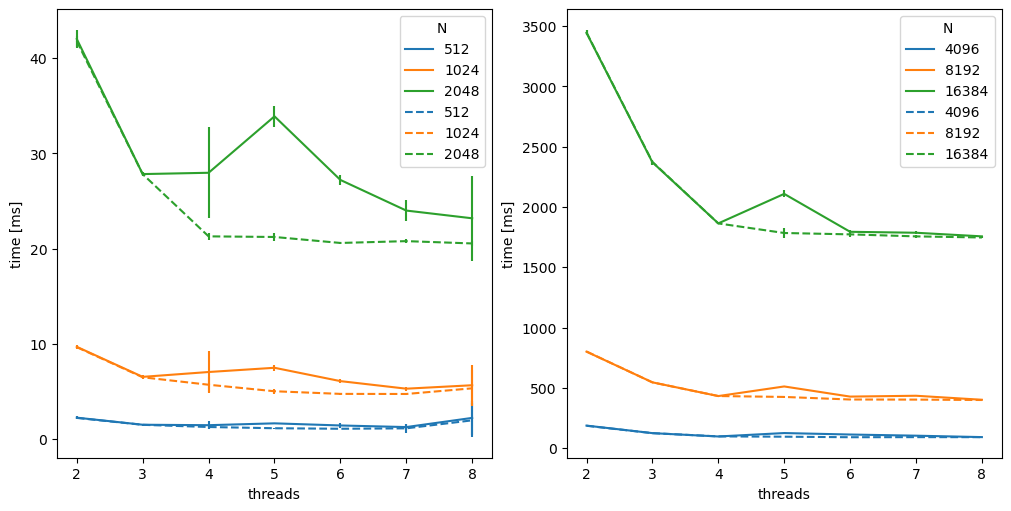

In [20]:
statDyn = data.groupby(["threads", 'N'])[["FFTStat", "FFTDyn"]].agg(["mean", "std"])*1000
fig, ax = plt.subplots(1,2, figsize=(10, 5), layout="constrained")
statDyn["FFTStat"].drop([4096, 8192, 16384], level=1).unstack().plot(y="mean", yerr="std", ylabel="time [ms]", layout="constrained", ax=ax[0])
ax[0].set_prop_cycle(None)
statDyn["FFTDyn"].drop([4096, 8192, 16384], level=1).unstack().plot(y="mean", yerr="std", ls='--', ax=ax[0])

statDyn["FFTStat"].drop([512,1024,2048], level=1).unstack().plot(y="mean", yerr="std", ylabel="time [ms]", layout="constrained", ax=ax[1])
ax[1].set_prop_cycle(None)
statDyn["FFTDyn"].drop([512,1024,2048], level=1).unstack().plot(y="mean", yerr="std", ls='--', ax=ax[1])
plt.show()

In [15]:
data.columns

Index(['threads', 'N', 'center', 'rev', 'FFTStat', 'FFTDyn', 'T', 'Gauss',
       'IFFT'],
      dtype='str')

In [ ]:
statDyn = data.groupby(["threads", 'N'])[["FFTStat", "FFTDyn"]].agg(["mean", "std"])*1000
fig, ax = plt.subplots(1,2, figsize=(10, 5), layout="constrained")
statDyn["FFTStat"].drop([4096, 8192, 16384], level=1).unstack().plot(y="mean", yerr="std", ylabel="time [ms]", layout="constrained", ax=ax[0])
ax[0].set_prop_cycle(None)
statDyn["FFTDyn"].drop([4096, 8192, 16384], level=1).unstack().plot(y="mean", yerr="std", ylabel="time [ms]", ls='--', layout="constrained", ax=ax[0])

statDyn["FFTStat"].drop([512,1024,2048], level=1).unstack().plot(y="mean", yerr="std", ylabel="time [ms]", layout="constrained", ax=ax[1])
ax[1].set_prop_cycle(None)
statDyn["FFTDyn"].drop([512,1024,2048], level=1).unstack().plot(y="mean", yerr="std", ylabel="time [ms]", ls='--', layout="constrained", ax=ax[1])
plt.show()